In [1]:
!pip install python-binance pandas numpy

import pandas as pd
import numpy as np
from binance.client import Client
from datetime import datetime

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [2]:
client = Client()

In [3]:
coins = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "ADAUSDT",
    "XRPUSDT", "DOGEUSDT", "AVAXUSDT", "DOTUSDT", "LINKUSDT"
]

interval = Client.KLINE_INTERVAL_1HOUR

start_date = "2020-01-01"



In [4]:
def load_coin_data(symbol, interval, start_date):
    klines = client.get_historical_klines(
        symbol=symbol,
        interval=interval,
        start_str=start_date

    )

    df = pd.DataFrame(klines, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_asset_volume",
        "taker_buy_quote_asset_volume",
        "ignore"
    ])

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df.set_index("open_time", inplace=True)

    df[["open", "high", "low", "close", "volume"]] = df[
        ["open", "high", "low", "close", "volume"]
    ].astype(float)

    df = df[["open", "high", "low", "close", "volume"]]

    return df


In [5]:
all_data = {}

for coin in coins:
    print(f"Loading {coin}...")
    df = load_coin_data(coin, interval, start_date)
    all_data[coin] = df


Loading BTCUSDT...
Loading ETHUSDT...
Loading BNBUSDT...
Loading SOLUSDT...
Loading ADAUSDT...
Loading XRPUSDT...
Loading DOGEUSDT...
Loading AVAXUSDT...
Loading DOTUSDT...
Loading LINKUSDT...


In [6]:
all_data["BTCUSDT"].head()
all_data["BTCUSDT"].info()



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 53138 entries, 2020-01-01 00:00:00 to 2026-01-24 09:00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    53138 non-null  float64
 1   high    53138 non-null  float64
 2   low     53138 non-null  float64
 3   close   53138 non-null  float64
 4   volume  53138 non-null  float64
dtypes: float64(5)
memory usage: 2.4 MB


In [7]:
for coin in coins:
    print(coin, len(all_data[coin]))


BTCUSDT 53138
ETHUSDT 53138
BNBUSDT 53138
SOLUSDT 47792
ADAUSDT 53138
XRPUSDT 53138
DOGEUSDT 53138
AVAXUSDT 46784
DOTUSDT 47607
LINKUSDT 53138


In [8]:
for coin, df in all_data.items():
    print(f"{coin} missing values:")
    print(df.isnull().sum())
    print("-" * 30)


BTCUSDT missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64
------------------------------
ETHUSDT missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64
------------------------------
BNBUSDT missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64
------------------------------
SOLUSDT missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64
------------------------------
ADAUSDT missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64
------------------------------
XRPUSDT missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64
------------------------------
DOGEUSDT missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64
------------------------------
AVAXUSDT missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64
-----

In [9]:
for coin, df in all_data.items():
    duplicates = df.index.duplicated().sum()
    print(f"{coin} duplicate timestamps: {duplicates}")


BTCUSDT duplicate timestamps: 0
ETHUSDT duplicate timestamps: 0
BNBUSDT duplicate timestamps: 0
SOLUSDT duplicate timestamps: 0
ADAUSDT duplicate timestamps: 0
XRPUSDT duplicate timestamps: 0
DOGEUSDT duplicate timestamps: 0
AVAXUSDT duplicate timestamps: 0
DOTUSDT duplicate timestamps: 0
LINKUSDT duplicate timestamps: 0


In [10]:
start_dates = [df.index.min() for df in all_data.values()]
end_dates = [df.index.max() for df in all_data.values()]

common_start = max(start_dates)
common_end = min(end_dates)

print("Common start:", common_start)
print("Common end:", common_end)


Common start: 2020-09-22 06:00:00
Common end: 2026-01-24 09:00:00


In [11]:
for coin in all_data:
    all_data[coin] = all_data[coin].loc[common_start:common_end]


In [12]:
for coin, df in all_data.items():
    missing = df.isnull().sum().sum()
    print(coin, "total missing:", missing)


BTCUSDT total missing: 0
ETHUSDT total missing: 0
BNBUSDT total missing: 0
SOLUSDT total missing: 0
ADAUSDT total missing: 0
XRPUSDT total missing: 0
DOGEUSDT total missing: 0
AVAXUSDT total missing: 0
DOTUSDT total missing: 0
LINKUSDT total missing: 0


In [13]:
for coin, df in all_data.items():
    print(coin, df.shape, df.index.is_monotonic_increasing)


BTCUSDT (46784, 5) True
ETHUSDT (46784, 5) True
BNBUSDT (46784, 5) True
SOLUSDT (46784, 5) True
ADAUSDT (46784, 5) True
XRPUSDT (46784, 5) True
DOGEUSDT (46784, 5) True
AVAXUSDT (46784, 5) True
DOTUSDT (46784, 5) True
LINKUSDT (46784, 5) True


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [15]:
for coin, df in all_data.items():
    print(f"\n{coin} statistics:")
    display(df.describe())



BTCUSDT statistics:


,open,high,low,close,volume
count,46784.000000,46784.000000,46784.000000,46784.000000,46784.000000
mean,52871.827772,53078.404510,52656.163304,52873.520317,3072.075548
std,30065.640030,30141.958177,29986.739012,30065.480344,4608.206485
min,10230.400000,10272.860000,10136.820000,10230.390000,0.000000
25%,27828.910000,27930.095000,27711.892500,27830.805000,764.035870
50%,44150.965000,44363.570000,43943.635000,44150.960000,1514.000466
75%,68539.992500,68775.180000,68321.065000,68540.037500,3328.959972
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600



ETHUSDT statistics:


,open,high,low,close,volume
count,46784.000000,46784.000000,46784.000000,46784.000000,46784.000000
mean,2434.634563,2447.601973,2420.798281,2434.689730,25075.412023
std,996.422180,1001.376950,991.018902,996.378832,27388.293842
min,320.720000,323.400000,313.290000,320.720000,0.000000
25%,1685.217500,1694.745000,1676.492500,1685.255000,9534.865375
50%,2385.040000,2403.885000,2367.350000,2385.360000,16765.406500
75%,3184.290000,3202.717500,3165.832500,3184.287500,30523.865450
max,4935.010000,4956.780000,4897.310000,4935.000000,508838.404900



BNBUSDT statistics:


...

,open,high,low,close,volume
count,46784.000000,46784.000000,46784.000000,46784.000000,4.678400e+04
mean,29.536232,29.809574,29.250356,29.536240,1.212328e+05
std,23.085764,23.332495,22.822383,23.085584,1.523061e+05
min,0.850000,2.841500,0.850000,2.821200,0.000000e+00
25%,14.630000,14.720000,14.560000,14.630000,4.227347e+04
50%,22.230000,22.420000,22.050000,22.230000,7.643452e+04
75%,35.530000,35.840000,35.180000,35.530000,1.410901e+05
max,144.000000,147.000000,141.300000,144.000000,4.305326e+06



DOTUSDT statistics:


,open,high,low,close,volume
count,46784.000000,46784.000000,46784.000000,46784.000000,4.678400e+04
mean,10.861278,10.956756,10.758769,10.861045,3.484170e+05
std,10.572515,10.686458,10.450406,10.572522,4.545335e+05
min,1.661000,1.689000,0.633000,1.662000,0.000000e+00
25%,4.455000,4.478375,4.428950,4.455000,1.185859e+05
50%,6.280000,6.315000,6.240000,6.279500,2.180726e+05
75%,10.843500,10.982500,10.700000,10.842250,4.076148e+05
max,55.030000,55.090000,53.800000,55.030000,1.517284e+07



LINKUSDT statistics:


,open,high,low,close,volume
count,46784.000000,46784.000000,46784.000000,46784.000000,4.678400e+04
mean,15.319668,15.446385,15.185722,15.319611,2.462425e+05
std,7.819036,7.909998,7.721168,7.818944,2.757080e+05
min,4.976000,5.024000,4.761000,4.976000,0.000000e+00
25%,7.926750,7.980000,7.861000,7.924000,9.501895e+04
50%,13.974000,14.070000,13.879650,13.974950,1.680084e+05
75%,19.310000,19.490000,19.130000,19.310000,2.962764e+05
max,52.277000,53.000000,51.600000,52.269000,7.888291e+06


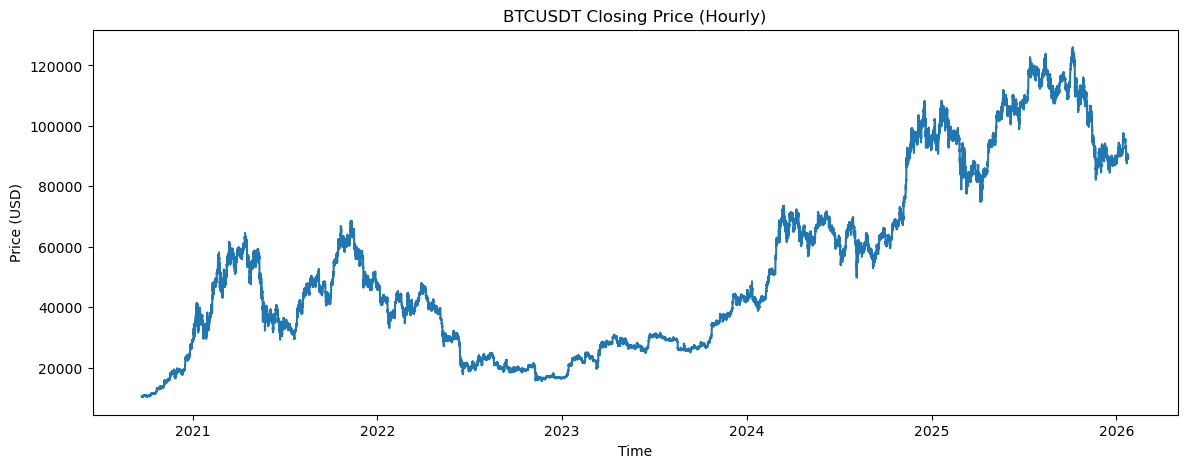

In [16]:
btc = all_data["BTCUSDT"]

plt.figure(figsize=(14,5))
plt.plot(btc.index, btc["close"])
plt.title("BTCUSDT Closing Price (Hourly)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.show()


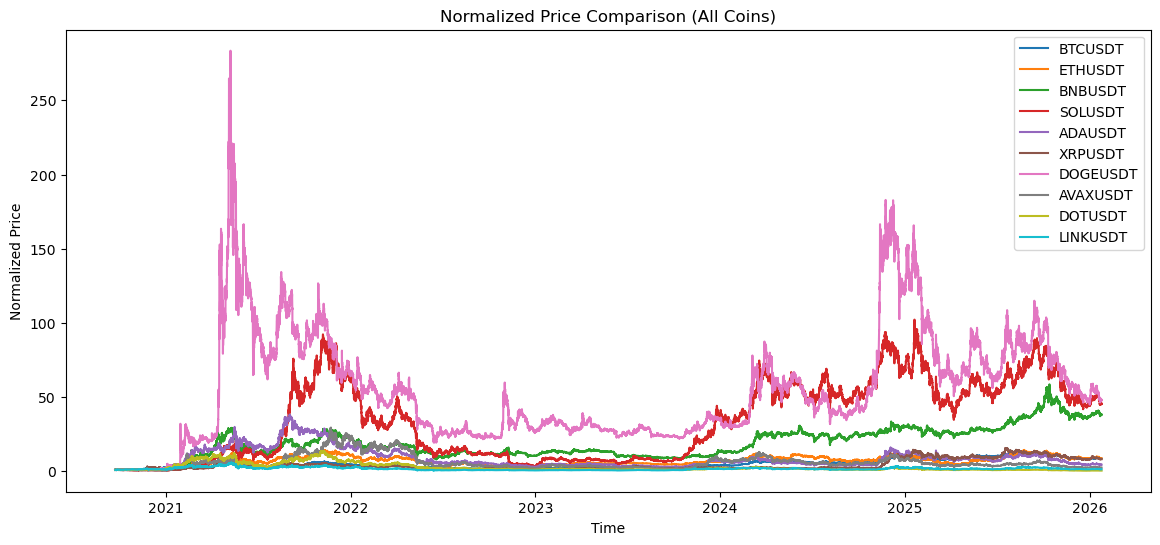

In [17]:
plt.figure(figsize=(14,6))

for coin in coins:
    normalized_price = all_data[coin]["close"] / all_data[coin]["close"].iloc[0]
    plt.plot(normalized_price, label=coin)

plt.title("Normalized Price Comparison (All Coins)")
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()


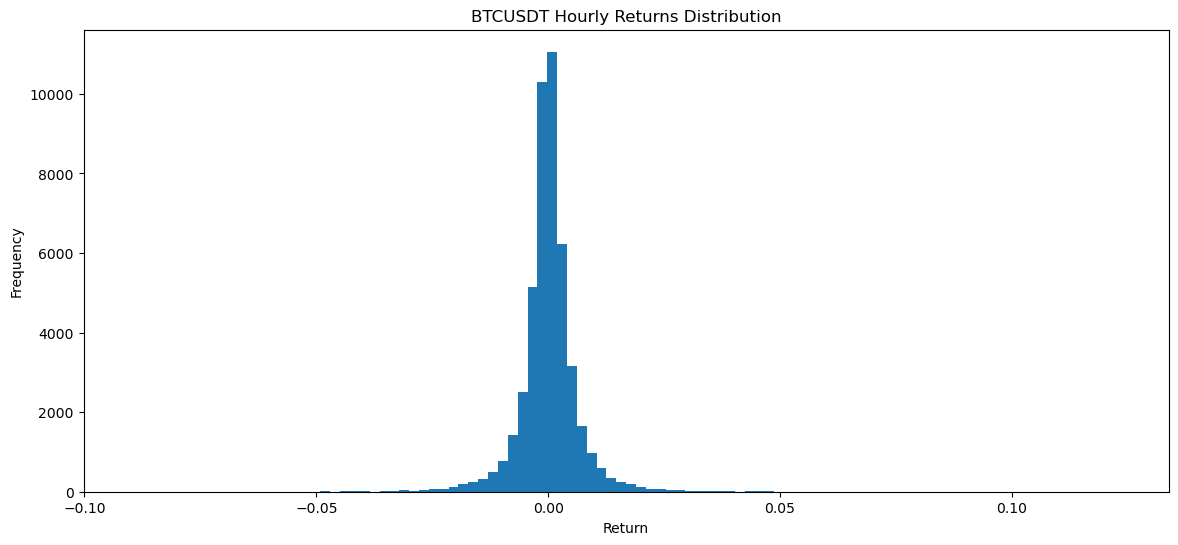

In [18]:
plt.figure(figsize=(14,6))

btc_returns = btc["close"].pct_change().dropna()
plt.hist(btc_returns, bins=100)
plt.title("BTCUSDT Hourly Returns Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()


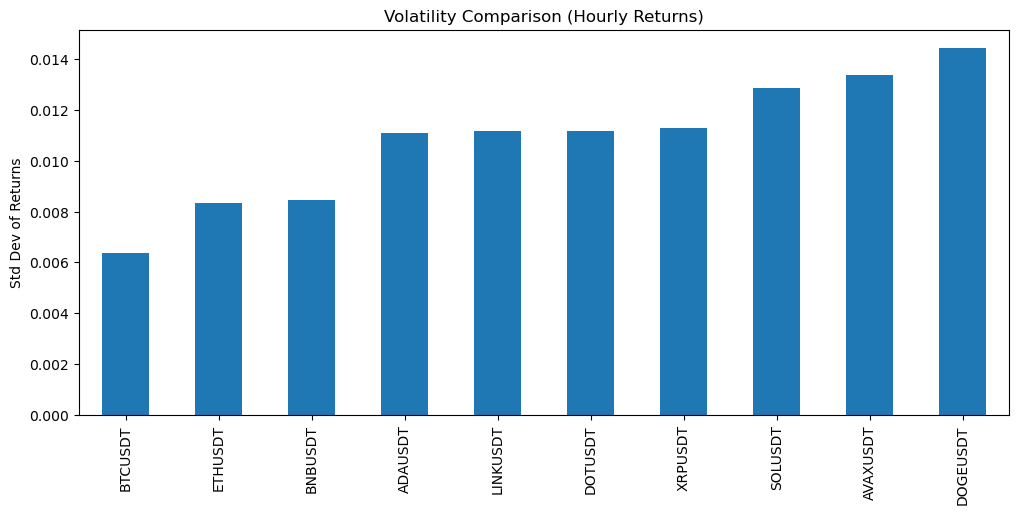

In [19]:
volatility = {}

for coin, df in all_data.items():
    volatility[coin] = df["close"].pct_change().std()

vol_df = pd.DataFrame.from_dict(volatility, orient="index", columns=["Volatility"])

vol_df.sort_values("Volatility").plot(
    kind="bar", figsize=(12,5), legend=False
)

plt.title("Volatility Comparison (Hourly Returns)")
plt.ylabel("Std Dev of Returns")
plt.show()


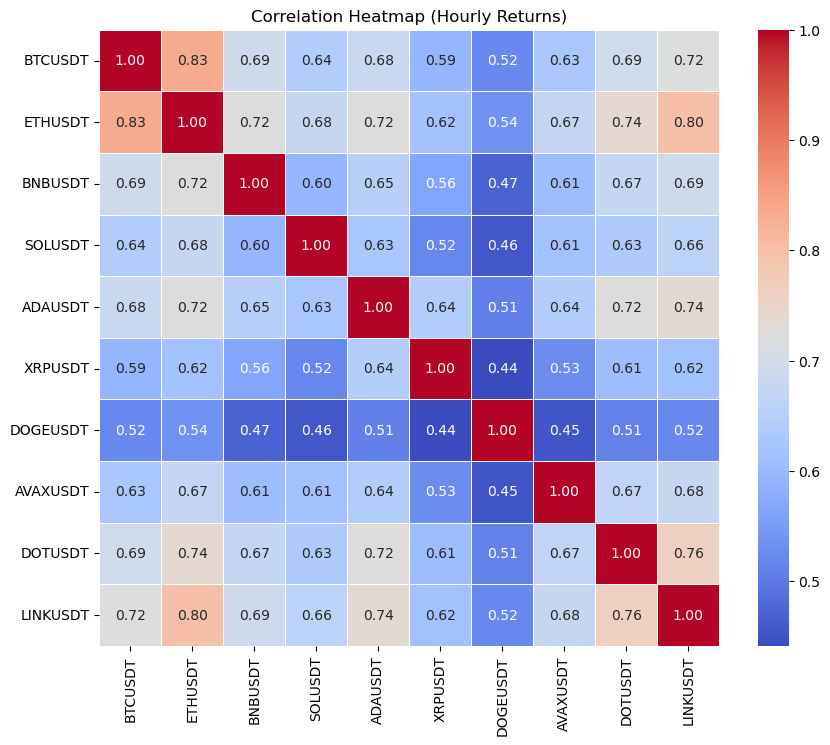

In [20]:
close_prices = pd.DataFrame({
    coin: all_data[coin]["close"] for coin in coins
})


returns = close_prices.pct_change().dropna()


plt.figure(figsize=(10, 8))
sns.heatmap(
    returns.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Hourly Returns)")
plt.show()



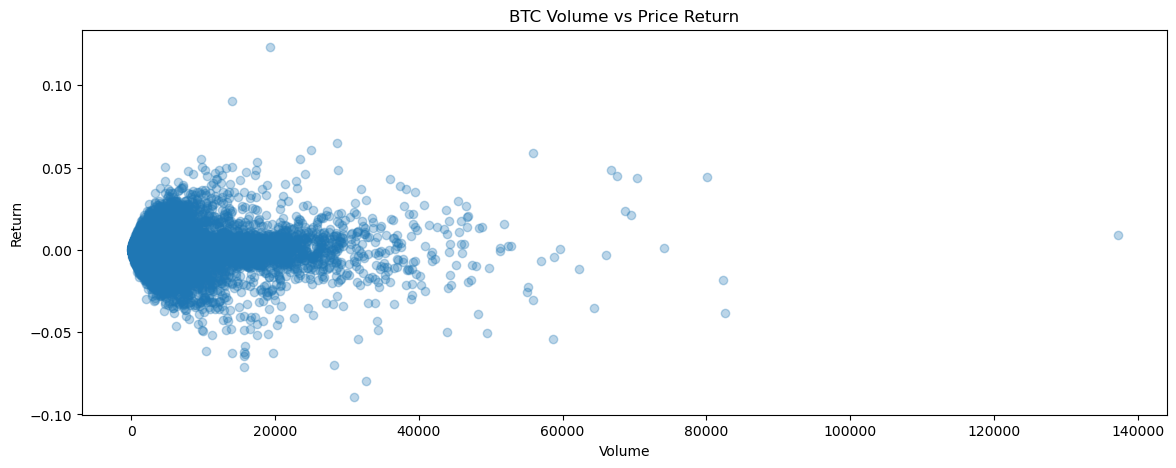

In [21]:
plt.figure(figsize=(14,5))

plt.scatter(
    btc["volume"],
    btc["close"].pct_change(),
    alpha=0.3
)

plt.title("BTC Volume vs Price Return")
plt.xlabel("Volume")
plt.ylabel("Return")
plt.show()


In [22]:
def add_target_direction(df):
    df = df.copy()
    df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)
    return df.dropna()

for coin in coins:
    all_data[coin] = add_target_direction(all_data[coin])


In [23]:
for coin in coins:
    print(coin, all_data[coin]["target"].value_counts(normalize=True))


BTCUSDT target
1    0.507438
0    0.492562
Name: proportion, dtype: float64
ETHUSDT target
1    0.507161
0    0.492839
Name: proportion, dtype: float64
BNBUSDT target
1    0.505814
0    0.494186
Name: proportion, dtype: float64
SOLUSDT target
0    0.501753
1    0.498247
Name: proportion, dtype: float64
ADAUSDT target
0    0.508165
1    0.491835
Name: proportion, dtype: float64
XRPUSDT target
1    0.50389
0    0.49611
Name: proportion, dtype: float64
DOGEUSDT target
0    0.500299
1    0.499701
Name: proportion, dtype: float64
AVAXUSDT target
0    0.515069
1    0.484931
Name: proportion, dtype: float64
DOTUSDT target
0    0.509191
1    0.490809
Name: proportion, dtype: float64
LINKUSDT target
0    0.507246
1    0.492754
Name: proportion, dtype: float64


In [24]:
def add_ema(df, period=20):
    df[f"ema_{period}"] = df["close"].ewm(span=period, adjust=False).mean()
    return df

def add_rsi(df, period=14):
    delta = df["close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    df["rsi"] = 100 - (100 / (1 + rs))
    return df

def add_macd(df):
    exp1 = df["close"].ewm(span=12, adjust=False).mean()
    exp2 = df["close"].ewm(span=26, adjust=False).mean()
    df["macd"] = exp1 - exp2
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"] = df["macd"] - df["macd_signal"]
    return df

def add_volatility(df, period=20):
    df["returns"] = df["close"].pct_change()
    df[f"volatility_{period}"] = df["returns"].rolling(window=period).std()
    return df


In [25]:
for coin in coins:
    df = all_data[coin]

    df = add_ema(df, 20)
    df = add_ema(df, 50)
    df = add_rsi(df, 14)
    df = add_macd(df)
    df = add_volatility(df, 20)

    df = df.dropna()  # remove NaNs from indicators

    all_data[coin] = df


In [26]:
all_data["BTCUSDT"].head()


,open,high,low,close,volume,target,ema_20,ema_50,rsi,macd,macd_signal,macd_hist,returns,volatility_20
open_time,,,,,,,,,,,,,,
2020-09-23 02:00:00,10515.02,10527.70,10501.93,10513.93,696.441134,0,10487.042308,10458.792597,55.424799,23.166689,20.578259,2.588430,-0.000104,0.002990
2020-09-23 03:00:00,10513.94,10516.03,10471.72,10476.01,1664.816333,0,10485.991612,10459.467790,50.481775,19.397278,20.342063,-0.944785,-0.003607,0.002887
2020-09-23 04:00:00,10476.00,10485.20,10441.91,10470.32,1738.945690,1,10484.499077,10459.893367,56.492665,15.769080,19.427466,-3.658386,-0.000543,0.002150
2020-09-23 05:00:00,10470.33,10490.84,10451.33,10473.22,1451.180060,0,10483.424879,10460.415980,54.807901,12.978110,18.137595,-5.159485,0.000277,0.002135
2020-09-23 06:00:00,10473.21,10478.91,10403.00,10436.48,2085.971611,0,10478.953939,10459.477314,46.454777,7.712727,16.052621,-8.339894,-0.003508,0.002277


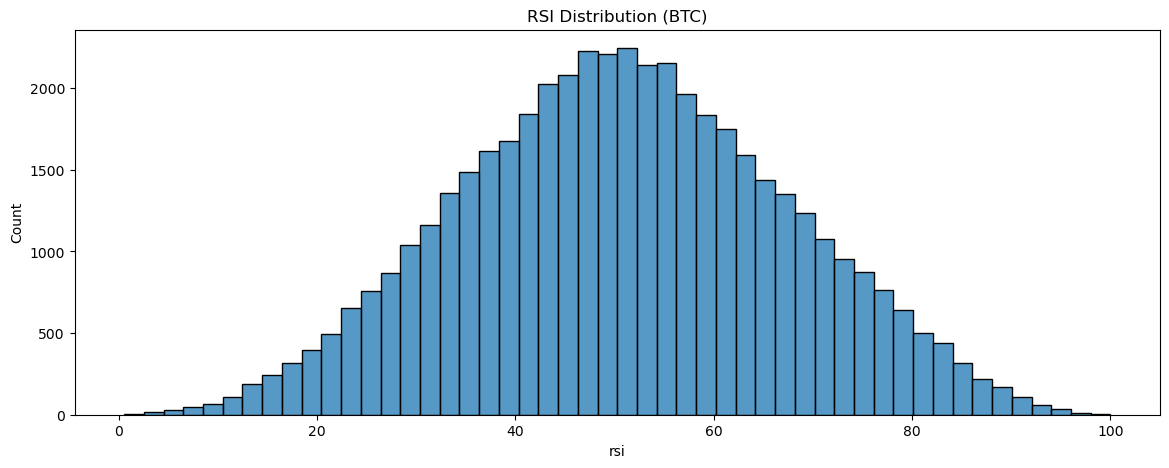

In [27]:
plt.figure(figsize=(14,5))
sns.histplot(all_data["BTCUSDT"]["rsi"], bins=50)
plt.title("RSI Distribution (BTC)")
plt.show()


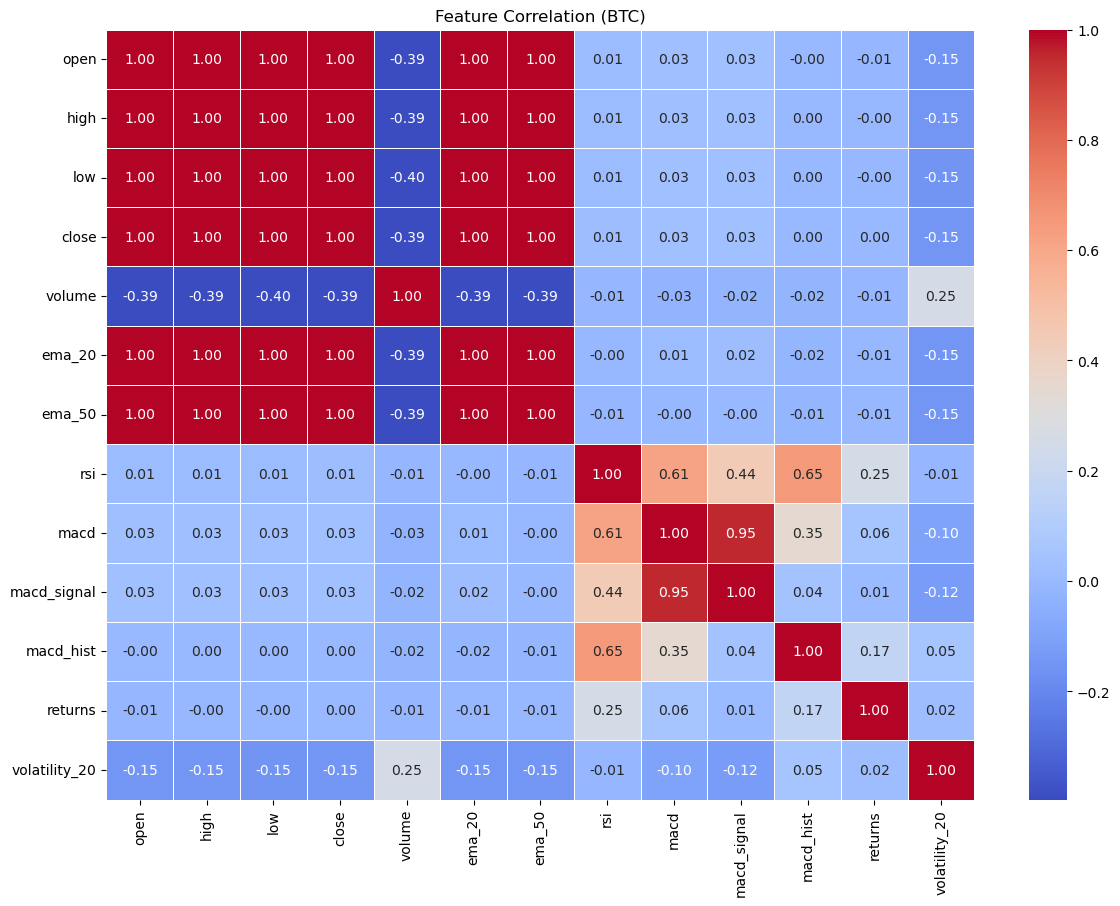

In [28]:
features = all_data["BTCUSDT"].drop(columns=["target"])

plt.figure(figsize=(14, 10))
sns.heatmap(
    features.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation (BTC)")
plt.show()


In [29]:
def train_test_split_time_series(df, train_ratio=0.8):
    split_index = int(len(df) * train_ratio)
    train_df = df.iloc[:split_index]
    test_df = df.iloc[split_index:]
    return train_df, test_df


In [30]:
from sklearn.preprocessing import StandardScaler

def scale_data(train_df, test_df, feature_cols):
    scaler = StandardScaler()
    scaler.fit(train_df[feature_cols])

    train_scaled = scaler.transform(train_df[feature_cols])
    test_scaled = scaler.transform(test_df[feature_cols])

    return scaler, train_scaled, test_scaled


In [31]:
coin = "BTCUSDT"
df = all_data[coin]

feature_cols = [
    "open", "high", "low", "close", "volume",
    "ema_20", "ema_50",
    "rsi",
    "macd", "macd_signal", "macd_hist",
    "returns", "volatility_20"
]

train_df, test_df = train_test_split_time_series(df)

scaler, train_scaled, test_scaled = scale_data(train_df, test_df, feature_cols)

print("Train shape:", train_scaled.shape)
print("Test shape:", test_scaled.shape)


Train shape: (37411, 13)
Test shape: (9353, 13)


In [32]:
print("Train target distribution:")
print(train_df["target"].value_counts(normalize=True))

print("\nTest target distribution:")
print(test_df["target"].value_counts(normalize=True))


Train target distribution:
target
1    0.508433
0    0.491567
Name: proportion, dtype: float64

Test target distribution:
target
1    0.503368
0    0.496632
Name: proportion, dtype: float64


In [33]:
!pip install xgboost


In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

coin = "BTCUSDT"
df = all_data[coin]

feature_cols = [
    "open", "high", "low", "close", "volume",
    "ema_20", "ema_50",
    "rsi",
    "macd", "macd_signal", "macd_hist",
    "returns", "volatility_20"
]

train_df, test_df = train_test_split_time_series(df)

X_train = train_df[feature_cols]
y_train = train_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]


In [35]:
model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [36]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.5137389073024698
Confusion Matrix:
[[1740 2905]
 [1643 3065]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.37      0.43      4645
           1       0.51      0.65      0.57      4708

    accuracy                           0.51      9353
   macro avg       0.51      0.51      0.50      9353
weighted avg       0.51      0.51      0.50      9353



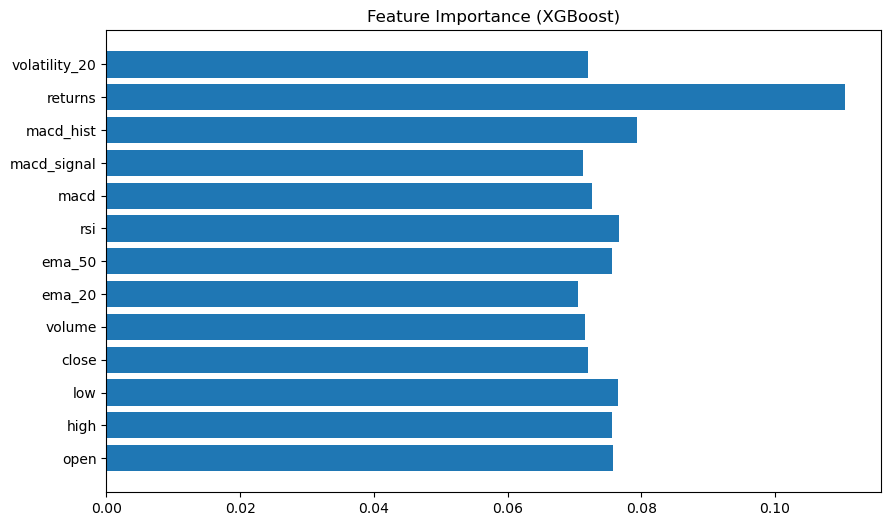

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_cols, model.feature_importances_)
plt.title("Feature Importance (XGBoost)")
plt.show()


In [38]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = {}

for coin in coins:
    print(f"Training {coin}...")

    df = all_data[coin]
    
    train_df, test_df = train_test_split_time_series(df)

    X_train = train_df[feature_cols]
    y_train = train_df["target"]

    X_test = test_df[feature_cols]
    y_test = test_df["target"]

    model = XGBClassifier(
        objective="binary:logistic",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[coin] = {
        "model": model,
        "accuracy": acc,
        "confusion_matrix": cm,
        "classification_report": classification_report(y_test, y_pred)
    }

    print(f"{coin} Accuracy: {acc:.4f}")
    print("-" * 40)

print("✅ All coins trained!")


Training BTCUSDT...


E:\Python\anaconda\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:41:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


BTCUSDT Accuracy: 0.5137
----------------------------------------
Training ETHUSDT...


E:\Python\anaconda\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:41:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ETHUSDT Accuracy: 0.5176
----------------------------------------
Training BNBUSDT...


...

AVAXUSDT Accuracy: 0.5104
----------------------------------------
Training DOTUSDT...


E:\Python\anaconda\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:41:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


DOTUSDT Accuracy: 0.4910
----------------------------------------
Training LINKUSDT...


E:\Python\anaconda\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:41:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


LINKUSDT Accuracy: 0.5233
----------------------------------------
✅ All coins trained!


In [39]:
accuracy_df = pd.DataFrame({
    coin: results[coin]["accuracy"] for coin in coins
}, index=["Accuracy"]).T

accuracy_df.sort_values("Accuracy", ascending=False)


,Accuracy
ADAUSDT,0.528173
LINKUSDT,0.523255
ETHUSDT,0.517588
DOGEUSDT,0.514167
BTCUSDT,0.513739
XRPUSDT,0.513525
SOLUSDT,0.511814
AVAXUSDT,0.510424
BNBUSDT,0.500802
DOTUSDT,0.490965


In [40]:
print(results["BTCUSDT"]["classification_report"])
print(results["ETHUSDT"]["classification_report"])
print(results["LINKUSDT"]["classification_report"])
print(results["XRPUSDT"]["classification_report"])
print(results["DOGEUSDT"]["classification_report"])
print(results["SOLUSDT"]["classification_report"])
print(results["AVAXUSDT"]["classification_report"])
print(results["ADAUSDT"]["classification_report"])
print(results["BNBUSDT"]["classification_report"])
print(results["DOTUSDT"]["classification_report"])


              precision    recall  f1-score   support

           0       0.51      0.37      0.43      4645
           1       0.51      0.65      0.57      4708

    accuracy                           0.51      9353
   macro avg       0.51      0.51      0.50      9353
weighted avg       0.51      0.51      0.50      9353

              precision    recall  f1-score   support

           0       0.51      0.53      0.52      4586
           1       0.53      0.51      0.52      4767

    accuracy                           0.52      9353
   macro avg       0.52      0.52      0.52      9353
weighted avg       0.52      0.52      0.52      9353

              precision    recall  f1-score   support

           0       0.54      0.62      0.58      4900
           1       0.50      0.42      0.46      4453

    accuracy                           0.52      9353
   macro avg       0.52      0.52      0.52      9353
weighted avg       0.52      0.52      0.52      9353

              preci

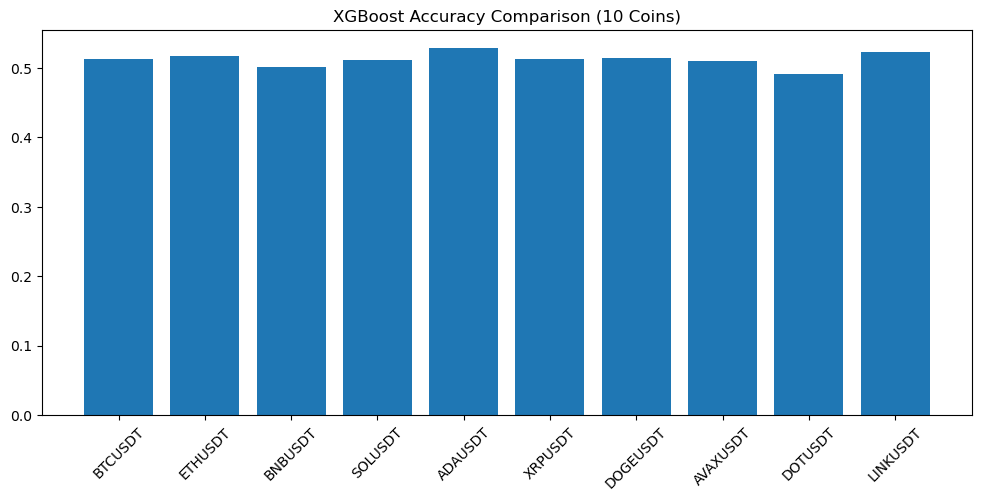

In [41]:
plt.figure(figsize=(12,5))
plt.bar(accuracy_df.index, accuracy_df["Accuracy"])
plt.title("XGBoost Accuracy Comparison (10 Coins)")
plt.xticks(rotation=45)
plt.show()


In [42]:
import joblib

for coin in coins:
    model = results[coin]["model"]
    joblib.dump(model, f"xgb_{coin}.joblib")

print("✅ All models saved.")



✅ All models saved.


In [43]:
def predict_next_direction(coin):
    # load model
    model = joblib.load(f"xgb_{coin}.joblib")
    
    # fetch latest 500 candles
    df = load_coin_data(coin, interval, "2020-01-01")

    # add features
    df = add_ema(df, 20)
    df = add_ema(df, 50)
    df = add_rsi(df, 14)
    df = add_macd(df)
    df = add_volatility(df, 20)

    df = df.dropna()

    # latest data
    latest = df.iloc[-1][feature_cols].values.reshape(1, -1)

    pred = model.predict(latest)[0]
    return "UP" if pred == 1 else "DOWN"


In [44]:
print("BTC prediction:", predict_next_direction("BTCUSDT"))


BTC prediction: UP


In [45]:
print("ETH prediction:", predict_next_direction("ETHUSDT"))

ETH prediction: UP


In [46]:
print("BNB prediction:", predict_next_direction("BNBUSDT"))

BNB prediction: DOWN


In [47]:
print("DOGE prediction:", predict_next_direction("DOGEUSDT"))

DOGE prediction: DOWN


In [48]:
print("ADA prediction:", predict_next_direction("ADAUSDT"))

ADA prediction: DOWN


In [49]:
print("SOL prediction:", predict_next_direction("SOLUSDT"))

SOL prediction: UP


In [50]:
print("AVAX prediction:", predict_next_direction("AVAXUSDT"))

AVAX prediction: DOWN


In [51]:
print("XRP prediction:", predict_next_direction("XRPUSDT"))

XRP prediction: UP


In [52]:
print("DOT prediction:", predict_next_direction("DOTUSDT"))

DOT prediction: UP


In [53]:
print("LINK prediction:", predict_next_direction("LINKUSDT"))

LINK prediction: DOWN
